# GEOLENS
## Overview
This notebook walks through building a point-supervised semantic segmentation pipeline for high-resolution aerial imagery.
Instead of full pixel-wise labels, we train using sparse point labels to reduce annotation cost while still achieving strong segmentation performance.

The project includes:

* Custom loss functions for partial supervision
* Point sampling from full masks
* A clean U-Net implementation
* A full training/validation loop
* Experiment configurations (learning rate, epochs, patience, etc.)

## Imports & Setup

In [3]:
# ! pip install segmentation-models-pytorch torchviz torchsummary mlflow python-dotenv --quiet

In [4]:
import os
import time
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import torchmetrics
import random
from torch.utils.data import Subset
    
import cv2
import albumentations as A

import glob
import shutil
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

ModuleNotFoundError: No module named 'torchmetrics'

## Loss Functions for Point Supervision

We implement two custom losses:

### Partial Cross-Entropy Loss

Computes CE only at labeled points, ignoring unlabeled pixels.

In [ ]:
class PartialCrossEntropyLoss(nn.Module):
    """
    Partial Cross-Entropy Loss for point-supervised learning.
    
    Formula: loss = sum(CE * mask) / sum(mask)
    
    Where:
    - CE is the per-pixel cross-entropy loss
    - mask is 1 for labeled pixels, 0 for unlabeled pixels
    - We normalize by the number of labeled pixels
    """
    
    def __init__(self, ignore_index=255):
        super().__init__()
        self.ignore_index = ignore_index
    
    def forward(self, predictions, labels):
        """
        Args:
            predictions: [B, C, H, W] - model predictions (logits)
            labels: [B, H, W] - sparse point labels (255 = unlabeled)
        
        Returns:
            loss: scalar tensor = sum(loss * mask) / sum(mask)
        """
        B, C, H, W = predictions.shape
        
        # Create binary mask for labeled pixels
        mask = (labels != self.ignore_index).float()  # [B, H, W]
        
        # Check if we have any labeled pixels
        num_labeled = mask.sum()
        if num_labeled == 0:
            return torch.tensor(0.0, device=predictions.device, requires_grad=True)
        
        # Compute per-pixel cross-entropy loss (no reduction)
        # CE expects [B, C, H, W] for predictions and [B, H, W] for targets
        ce_loss = F.cross_entropy(predictions, labels, 
                                  ignore_index=self.ignore_index, 
                                  reduction='none') # ce_loss shape: [B, H, W]
        
        # Apply mask and compute mean over labeled pixels only
        masked_loss = ce_loss * mask
        partial_loss = masked_loss.sum() / num_labeled
        
        return partial_loss

### Partial Focal Loss

Adds a focusing factor (1 - p)^γ to emphasize hard samples. Useful when using sparse labels.

In [ ]:
class PartialFocalLoss(nn.Module):
    """
    Partial Focal Loss for Point-Supervised Learning with Class Imbalance.
    
    Formula: loss = sum(FL * mask) / sum(mask)
    Where FL = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Focal loss down-weights easy examples and focuses on hard examples.
    Combined with partial supervision for point-based learning.
    """
    
    def __init__(self, alpha=1.0, gamma=2.0, ignore_index=255):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
    
    def forward(self, predictions, labels):
        """
        Args:
            predictions: [B, C, H, W] - model predictions (logits)
            labels: [B, H, W] - sparse point labels (255 = unlabeled)
        
        Returns:
            focal_loss: scalar tensor
        """
        B, C, H, W = predictions.shape
        
        # Create binary mask for labeled pixels
        mask = (labels != self.ignore_index).float()
        num_labeled = mask.sum()
        
        if num_labeled == 0:
            return torch.tensor(0.0, device=predictions.device, requires_grad=True)
        
        # Get probabilities
        probs = F.softmax(predictions, dim=1)  # [B, C, H, W]
        
        # Gather probabilities for true class
        labels_one_hot = F.one_hot(labels.clamp(0, C-1), num_classes=C)  # [B, H, W, C]
        labels_one_hot = labels_one_hot.permute(0, 3, 1, 2).float()  # [B, C, H, W]
        
        # Get probability of true class p_t
        p_t = (probs * labels_one_hot).sum(dim=1)  # [B, H, W]
        
        # Compute focal weight: (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma
        
        # Compute cross-entropy: -log(p_t)
        ce_loss = F.cross_entropy(predictions, 
                                  labels, 
                                  ignore_index=self.ignore_index, 
                                  reduction='none')
        
        # Apply focal weight and mask
        focal_loss = self.alpha * focal_weight * ce_loss * mask
        
        return focal_loss.sum() / num_labeled

## Point Label Sampling

Since annotated points are sparse, this function:

* Reads the full mask
* Randomly selects N pixels per class
* Returns a point-label mask used during training

In [ ]:
def sample_point_labels(full_mask, num_points_per_class=10, strategy='random'):
    """
    Convert dense segmentation mask to sparse point labels.
    
    Args:
        full_mask: [H, W] numpy array with class labels
        num_points_per_class: number of points to sample per class
        strategy: 'random', 'stratified', or 'clustered'
    
    Returns:
        point_mask: [H, W] sparse mask with 255 for unlabeled pixels
    """
    H, W = full_mask.shape
    point_mask = np.full((H, W), 255, dtype=np.int64)
    
    # Get unique classes (excluding ignore index)
    classes = np.unique(full_mask)
    classes = classes[classes != 255]
    
    for class_id in classes:
        # Find all pixels of this class
        y_coords, x_coords = np.where(full_mask == class_id)
        
        if len(y_coords) == 0:
            continue
        
        # Sample points based on strategy
        num_samples = min(num_points_per_class, len(y_coords))
        
        if strategy == 'random':
            indices = np.random.choice(len(y_coords), num_samples, replace=False)
        else:
            # Sample uniformly across spatial regions
            indices = np.linspace(0, len(y_coords)-1, num_samples, dtype=int)
    
        # Mark sampled points
        for idx in indices:
            point_mask[y_coords[idx], x_coords[idx]] = class_id
    
    return point_mask

## Model Architecture: U-Net

We implement U-Net from scratch:

* Encoder (downsampling)
* Bottleneck
* Decoder with skip connections
* Final segmentation head

In [ ]:
class DoubleConv(nn.Module):
    """Double convolution block with BatchNorm and ReLU"""
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    """
    U-Net architecture for semantic segmentation.
    Encoder-decoder structure with skip connections.
    """
    
    def __init__(self, in_channels=3, num_classes=5, features=[64, 128, 256, 512]):
        super().__init__()
        
        # Encoder (downsampling)
        self.encoder_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        
        for feature in features:
            self.encoder_blocks.append(DoubleConv(in_channels, feature))
            in_channels = feature
        
        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        
        # Decoder (upsampling)
        self.decoder_blocks = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        
        for feature in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(feature * 2, feature, 2, 2))
            self.decoder_blocks.append(DoubleConv(feature * 2, feature))
        
        # Final output layer
        self.output = nn.Conv2d(features[0], num_classes, 1)
    
    def forward(self, x):
        # Encoder path
        skip_connections = []
        for encoder in self.encoder_blocks:
            x = encoder(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder path
        skip_connections = skip_connections[::-1]
        for idx in range(len(self.decoder_blocks)):
            x = self.upconvs[idx](x)
            skip = skip_connections[idx]
            
            # Handle size mismatch
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            
            x = torch.cat([skip, x], dim=1)
            x = self.decoder_blocks[idx](x)
        
        return self.output(x)

## Dataset Class

This class:

* Loads RGB images & full masks from disk
* Generates point-label masks during training
* Applies preprocessing (resize, normalize, tensor conversion)

Works in both training and validation modes.

In [ ]:
class PointSupervisedDataset(Dataset):
    """
    Dataset for point-supervised segmentation.
    Automatically splits images into tiles if needed, then loads them.
    """

    def __init__(self, 
                 data_root='/kaggle/input/landcoverai',
                 mode='train',
                 num_points_per_class=10,
                 transforms=None,
                 image_size=512,
                 val_ratio=0.2,
                 seed=42):
        
        if mode not in {'train', 'val', 'test'}:
            raise ValueError(f"Mode must be 'train', 'val', or 'test', not '{mode}'")
        
        self.mode = mode
        self.transforms = transforms
        self.num_points = num_points_per_class
        self.data_root = data_root
        self.image_size = image_size
        
        # Output directory for tiles
        self.output_dir = os.path.join(os.getcwd(), "output")
        
        # Check if tiles exist, if not create them
        if not os.path.exists(self.output_dir) or len(glob.glob(os.path.join(self.output_dir, "*.jpg"))) == 0:
            print("Tiles not found. Creating tiles from original images...")
            self._split_images()
        
        # Get all image files (*.jpg files)
        all_files = sorted(glob.glob(os.path.join(self.output_dir, "*.jpg")))
        self.img_paths = [os.path.basename(f) for f in all_files]
        
        print(f"Found {len(self.img_paths)} total tile images")
        
        # Split into train/val/test
        train_val_paths, test_paths = train_test_split(
            self.img_paths, test_size=0.1, random_state=seed
        )
        train_paths, val_paths = train_test_split(
            train_val_paths, test_size=val_ratio, random_state=seed
        )

        if mode == 'train':
            self.img_paths = train_paths
        elif mode == 'val':
            self.img_paths = val_paths
        else:
            self.img_paths = test_paths

        print(f"{mode.upper()} dataset: {len(self.img_paths)} samples")

    def _split_images(self):
        """
        Splits original aerial images and masks into tiles.
        This is based on the working code you provided.
        """
        tic = time.time()
        
        # Clean and create output directory
        if Path(self.output_dir).exists():
            shutil.rmtree(self.output_dir)
        os.makedirs(self.output_dir)
        
        # Get original image and mask paths from separate folders
        imgs_dir = os.path.join(self.data_root, "images")
        masks_dir = os.path.join(self.data_root, "masks")
        
        img_paths = sorted(glob.glob(os.path.join(imgs_dir, "*.tif")))
        mask_paths = sorted(glob.glob(os.path.join(masks_dir, "*.tif")))
        
        print(f"Splitting {len(img_paths)} images into {self.image_size}x{self.image_size} tiles...")
        
        for img_path, mask_path in tqdm(zip(img_paths, mask_paths), total=len(img_paths), desc="Processing"):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path)
            
            if img is None or mask is None:
                print(f"Warning: Could not read {img_path} or {mask_path}")
                continue
            
            tile_count = 0
            for y in range(0, img.shape[0], self.image_size):
                for x in range(0, img.shape[1], self.image_size):
                    img_tile = img[y:y + self.image_size, x:x + self.image_size]
                    mask_tile = mask[y:y + self.image_size, x:x + self.image_size]
                    
                    # Only save if tile is full size
                    if img_tile.shape[:2] == (self.image_size, self.image_size):
                        base_name = os.path.splitext(os.path.basename(img_path))[0]
                        cv2.imwrite(f"{self.output_dir}/{base_name}_{tile_count}.jpg", img_tile)
                        cv2.imwrite(f"{self.output_dir}/{base_name}_{tile_count}_m.png", mask_tile)
                        tile_count += 1
        
        mins, sec = divmod(time.time() - tic, 60)
        print(f"Completed in {mins:.0f}m {sec:.2f}s")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_filename = self.img_paths[idx]
        
        # Image path: output/M-XX-XX_123.jpg
        img_path = os.path.join(self.output_dir, img_filename)
        
        # Mask path: output/M-XX-XX_123_m.png
        mask_filename = img_filename.replace('.jpg', '_m.png')
        mask_path = os.path.join(self.output_dir, mask_filename)

        # Load image
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        # Load mask - extract green channel
        mask = cv2.imread(mask_path)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        mask = mask[:, :, 1]  # Extract green channel

        # Apply augmentations
        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image, mask = transformed['image'], transformed['mask']

        # Sample points for training, use full mask for validation
        if self.mode == 'train':
            point_mask = sample_point_labels(mask, self.num_points)
        else:
            point_mask = mask.copy()

        # Convert to tensors
        image = torch.from_numpy(np.transpose(image, (2, 0, 1))).float() / 255.0
        point_mask = torch.from_numpy(point_mask).long()
        mask = torch.from_numpy(mask).long()

        return image, point_mask, mask


## Training Utilities

Includes:

* train_epoch
* validation
* Accuracy & IoU computation
* Early stopping

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for images, point_masks, _ in tqdm(loader, desc='Training'):
        images = images.to(device)
        point_masks = point_masks.to(device)
        
        # Forward pass
        predictions = model(images)
        loss = criterion(predictions, point_masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, num_classes, device):
    """Evaluate model on full masks"""
    model.eval()
    
    # Metrics
    iou_metric = torchmetrics.JaccardIndex(
        num_classes=num_classes, 
        task='multiclass',
        average='macro'
    ).to(device)
    
    acc_metric = torchmetrics.Accuracy(
        num_classes=num_classes,
        task='multiclass',
        average='micro'
    ).to(device)
    
    with torch.no_grad():
        for images, _, full_masks in tqdm(loader, desc='Evaluating'):
            images = images.to(device)
            full_masks = full_masks.to(device)
            
            # Predict
            predictions = model(images)
            preds = torch.argmax(predictions, dim=1)
            
            # Update metrics
            iou_metric.update(preds, full_masks)
            acc_metric.update(preds, full_masks)
    
    return iou_metric.compute().item(), acc_metric.compute().item()

## Experiment Runner

* Dataloaders
* Model initialization
* Optimizer (Adam)
* LR settings
* Whether to use CE or Focal Loss
* Metrics tracking
* Training loop & validation evaluation

Returns a dictionary with losses, IoU, and accuracy.

In [ ]:
def run_experiment(train_loader, val_loader, num_points, num_classes=5, 
                   epochs=30, lr=1e-4, patience=5, device='cuda', use_focal=False):
    """
    Run complete experiment with given number of points.
    
    Args:
        use_focal: If True, use Partial Focal Loss instead of Partial CE Loss
    
    Returns:
        results: dictionary with training history and metrics
    """
    loss_name = "Focal" if use_focal else "CE"
    print(f"EXPERIMENT: {num_points} points per class | Loss: Partial {loss_name}")
    
    # Initialize model
    model = UNet(in_channels=3, num_classes=num_classes).to(device)
    
    # Choose loss function
    if use_focal:
        criterion = PartialFocalLoss(alpha=1.0, gamma=2.0)
    else:
        criterion = PartialCrossEntropyLoss()
    
    optimizer = Adam(model.parameters(), lr=lr)
    
    # Training history
    train_losses = []
    val_ious = []
    val_accs = []
    best_iou = 0
    patience_counter = 0
    
    # Training loop
    for epoch in range(epochs):
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        
        # Validate
        val_iou, val_acc = evaluate(model, val_loader, num_classes, device)
        val_ious.append(val_iou)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {train_loss:.4f} | "
              f"Val mIoU: {val_iou:.4f} | "
              f"Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if val_iou > best_iou:
            best_iou = val_iou
            patience_counter = 0
            torch.save(model.state_dict(), f'best_model_{num_points}pts_{loss_name}.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    print(f"\nBest Val mIoU: {best_iou:.4f}")
    
    return {
        'num_points': num_points,
        'loss_type': loss_name,
        'train_losses': train_losses,
        'val_ious': val_ious,
        'val_accs': val_accs,
        'best_iou': best_iou,
        'model': model
    }

In [ ]:
def plot_results(results_list, save_path='experiment_results.png'):
    """Plot training curves for all experiments"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    colors = sns.color_palette("husl", len(results_list))
    
    for i, results in enumerate(results_list):
        loss_type = results.get('loss_type', 'CE')
        label = f"{results['num_points']} pts ({loss_type})"
        epochs = range(1, len(results['train_losses']) + 1)
        
        # Training loss
        axes[0].plot(epochs, results['train_losses'], 
                    label=label, color=colors[i], linewidth=2)
        
        # Validation mIoU
        axes[1].plot(epochs, results['val_ious'], 
                    label=label, color=colors[i], linewidth=2, marker='o')
        
        # Validation accuracy
        axes[2].plot(epochs, results['val_accs'], 
                    label=label, color=colors[i], linewidth=2, marker='s')
    
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('mIoU', fontsize=12)
    axes[1].set_title('Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Accuracy', fontsize=12)
    axes[2].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nResults saved to {save_path}")
    plt.show()

In [ ]:
def main():
    """Main execution function"""
    
    # Configuration
    DATA_ROOT = '/kaggle/input/landcoverai'
    NUM_CLASSES = 5
    IMAGE_SIZE = 512
    BATCH_SIZE = 2
    EPOCHS = 5
    LR = 1e-4
    PATIENCE = 2
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}\n")
    
    # Augmentations for training
    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(p=0.3)
    ])
    
    # EXPERIMENT: Effect of Point Density (10, 30 points per class)
    print("EXPERIMENT: ANNOTATION DENSITY")
    
    point_configs = [10, 30]
    density_results = []
    
    for num_points in point_configs:
        print(f"\n--- Running experiment with {num_points} points per class ---")
        
        # Create datasets
        train_dataset = PointSupervisedDataset(
            mode='train',
            data_root=DATA_ROOT,
            num_points_per_class=num_points,
            transforms=train_transforms,
            image_size=IMAGE_SIZE
        )
        
        val_dataset = PointSupervisedDataset(
            mode='val',
            data_root=DATA_ROOT,
            num_points_per_class=num_points,
            transforms=None,
            image_size=IMAGE_SIZE
        )
        
        # Data loaders
        train_loader = DataLoader(
            train_dataset, 
            batch_size=BATCH_SIZE, 
            shuffle=True, 
            num_workers=8
        )
        
        val_loader = DataLoader(
            val_dataset, 
            batch_size=BATCH_SIZE, 
            shuffle=False, 
            num_workers=8
        )
        
        # Run experiment
        results = run_experiment(
            train_loader=train_loader,
            val_loader=val_loader,
            num_points=num_points,
            num_classes=NUM_CLASSES,
            epochs=EPOCHS,
            lr=LR,
            patience=PATIENCE,
            device=device,
            use_focal=True
        )
        
        density_results.append(results)
    
    print("\nAll experiments completed.")
    
    # Plot results
    plot_results(density_results, save_path='experiment_results.png')
    
    # Print summary
    print("FINAL RESULTS SUMMARY")
    for result in density_results:
        print(f"{result['num_points']:2d} points | Best mIoU: {result['best_iou']:.4f}")
    
    return density_results

Using device: cuda

EXPERIMENT: ANNOTATION DENSITY

--- Running experiment with 10 points per class ---
Tiles not found. Creating tiles from original images...
Splitting 41 images into 512x512 tiles...


Processing: 100%|██████████| 41/41 [01:47<00:00,  2.63s/it]


Completed in 1m 47.83s
Found 10674 total tile images
TRAIN dataset: 7684 samples
Found 10674 total tile images
VAL dataset: 1922 samples
EXPERIMENT: 10 points per class | Loss: Partial Focal


Evaluating: 100%|██████████| 961/961 [01:20<00:00, 12.01it/s]


Epoch 01/5 | Loss: 0.5853 | Val mIoU: 0.3374 | Val Acc: 0.7166


...

Epoch 03/5 | Loss: 0.4210 | Val mIoU: 0.4561 | Val Acc: 0.7742


Evaluating: 100%|██████████| 961/961 [01:19<00:00, 12.10it/s]


Epoch 04/5 | Loss: 0.3890 | Val mIoU: 0.4393 | Val Acc: 0.7734


Evaluating: 100%|██████████| 961/961 [01:19<00:00, 12.11it/s]


Epoch 05/5 | Loss: 0.3646 | Val mIoU: 0.4419 | Val Acc: 0.7904
Early stopping at epoch 5

Best Val mIoU: 0.4561

All experiments completed.

Results saved to experiment_results.png


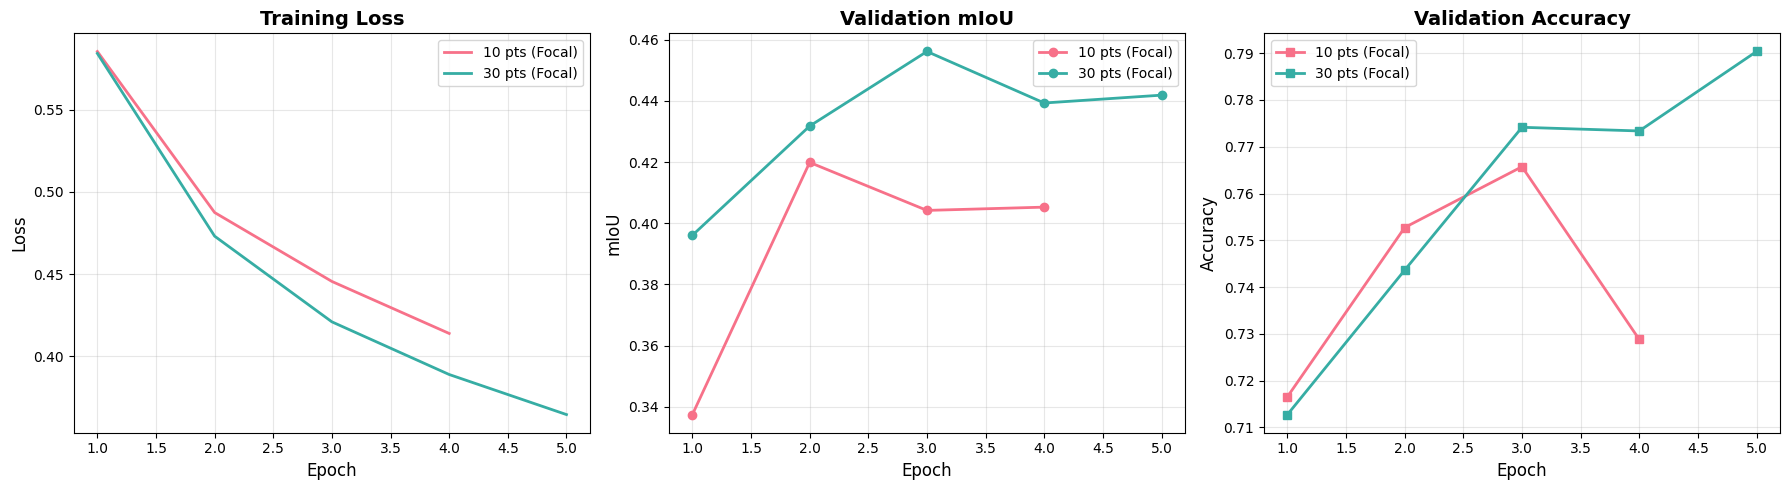

FINAL RESULTS SUMMARY
10 points | Best mIoU: 0.4199
30 points | Best mIoU: 0.4561


In [ ]:
if __name__ == "__main__":
    main()

**Increasing annotation density from 10 to 30 points per class improves model performance. Across all epochs, 30 points consistently achieve lower training loss, higher validation mIoU, and higher accuracy. Early stopping indicates faster convergence with more points. Therefore, using more points per class provides stronger supervision and better segmentation quality.**